# Week 08 - Wednesday Daily Assignment

**Topics Covered:**
- AM: CNNs - Convolution, Pooling, LeNet to ResNet, Transfer Learning
- PM: Embeddings - Word2Vec -> GloVe -> BERT -> Sentence-BERT, Cosine Similarity, Semantic Search

**Dataset:** Reddit_Data.csv (social media comments with sentiment categories)

**Structure:**
- Sub-step 1 (Easy): Load and characterise Reddit social media data
- Sub-step 2 (Easy): Load and characterise MNIST
- Sub-step 3 (Medium): Build and train a CNN on MNIST
- Sub-step 4 (Medium): Hate speech detector + semantic similarity system
- Sub-step 5 (Medium): Two-stage moderation pipeline evaluation
- Sub-step 6 (Hard/Optional): TF-IDF vs embeddings comparison
- Sub-step 7 (Hard/Optional): Transfer learning experiment

## Environment Setup

In [1]:
# Install required packages if not present
import subprocess
import sys

REQUIRED_PACKAGES = [
    "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn",
    "sentence-transformers", "torch", "torchvision"
]

for package in REQUIRED_PACKAGES:
    try:
        __import__(package.replace("-", "_"))
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

print("All packages ready.")

Installing scikit-learn...


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All packages ready.


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_class_weight

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

# Global constants
DATA_PATH = "./data/Reddit_Data.csv"
HATE_SPEECH_LABEL = -1
RANDOM_STATE = 42
TEST_SIZE = 0.2
TOP_K_SIMILAR = 5
DAILY_POST_VOLUME = 100_000
CNN_EPOCHS = 5
CNN_BATCH_SIZE = 64
CNN_LEARNING_RATE = 0.001
SIMILARITY_THRESHOLD = 0.75
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

print("Imports successful.")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Imports successful.
PyTorch version: 2.11.0
Device: cpu


---
## Sub-step 1 (Easy) - Load and Characterise the Social Media Dataset
**Objective:** Understand class distributions, data quality issues, and what the data tells us before any modelling.

In [3]:
def load_reddit_data(filepath):
    """
    Load Reddit social media CSV data from the given filepath.
    Returns a DataFrame and raises FileNotFoundError if file is missing.
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"Dataset not found at '{filepath}'. "
            "Please place Reddit_Data.csv in the same directory as this notebook."
        )
    df = pd.read_csv(filepath)
    print(f"Loaded {len(df):,} rows and {df.shape[1]} columns from '{filepath}'.")
    return df


def summarise_class_distribution(df, label_column, label_map):
    """
    Print and return a summary of class distribution in the given column.
    label_map is a dict mapping raw label values to human-readable names.
    """
    counts = df[label_column].value_counts().sort_index()
    total = len(df)
    summary = pd.DataFrame({
        "Label Name": [label_map.get(k, str(k)) for k in counts.index],
        "Count": counts.values,
        "Percentage": (counts.values / total * 100).round(2)
    }, index=counts.index)
    print("\nClass Distribution:")
    print(summary.to_string())
    return summary


def check_data_quality(df, text_column):
    """
    Inspect for nulls, empty strings, and duplicate rows in the DataFrame.
    Returns a dict with issue counts.
    """
    null_counts = df.isnull().sum()
    empty_text = (df[text_column].fillna("").str.strip() == "").sum()
    duplicate_rows = df.duplicated().sum()

    quality_report = {
        "null_per_column": null_counts.to_dict(),
        "empty_text_rows": int(empty_text),
        "duplicate_rows": int(duplicate_rows)
    }
    print("\nData Quality Report:")
    for key, val in quality_report.items():
        print(f"  {key}: {val}")
    return quality_report


def analyse_text_lengths(df, text_column):
    """
    Compute and display statistics about text length (word count) per row.
    """
    df = df.copy()
    df["word_count"] = df[text_column].fillna("").apply(lambda t: len(str(t).split()))
    stats = df["word_count"].describe().round(1)
    print("\nText Length Statistics (word count):")
    print(stats.to_string())
    return df


def plot_class_distribution(class_summary, label_map, title):
    """
    Plot a bar chart of class distribution.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    colors = ["#d9534f", "#5bc0de", "#5cb85c"]
    axes[0].bar(
        class_summary["Label Name"],
        class_summary["Count"],
        color=colors[:len(class_summary)]
    )
    axes[0].set_title(f"{title} - Count")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Number of Posts")
    for i, (count, pct) in enumerate(zip(class_summary["Count"], class_summary["Percentage"])):
        axes[0].text(i, count + 100, f"{pct}%", ha="center", fontsize=9)

    axes[1].pie(
        class_summary["Count"],
        labels=class_summary["Label Name"],
        autopct="%1.1f%%",
        colors=colors[:len(class_summary)],
        startangle=90
    )
    axes[1].set_title(f"{title} - Proportion")

    plt.tight_layout()
    plt.savefig("./images/class_distribution.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: class_distribution.png")

Loaded 37,249 rows and 2 columns from './data/Reddit_Data.csv'.

Column names: ['clean_comment', 'category']

First 3 rows:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

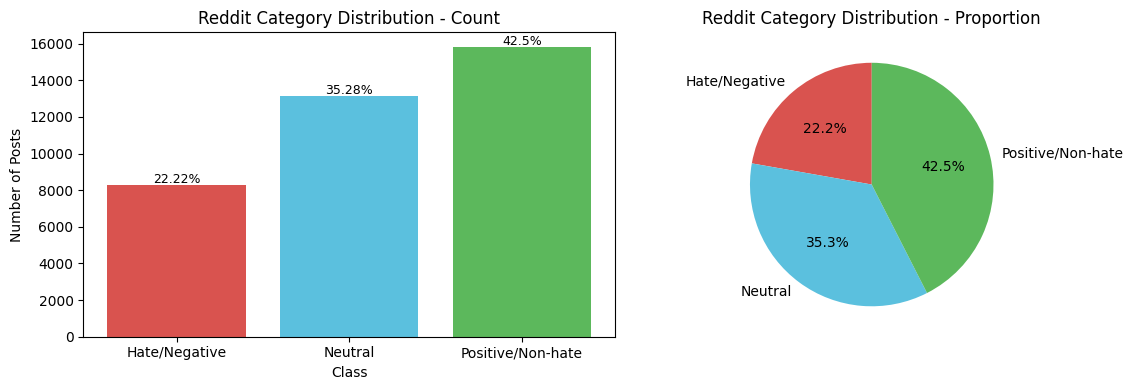

Saved: class_distribution.png


In [4]:
# --- Execute Sub-step 1 ---

CATEGORY_LABEL_MAP = {-1: "Hate/Negative", 0: "Neutral", 1: "Positive/Non-hate"}

try:
    reddit_df = load_reddit_data(DATA_PATH)
except FileNotFoundError as e:
    print(f"ERROR: {e}")
    raise

print("\nColumn names:", reddit_df.columns.tolist())
print("\nFirst 3 rows:")
print(reddit_df.head(3).to_string())

class_summary = summarise_class_distribution(reddit_df, "category", CATEGORY_LABEL_MAP)
quality_report = check_data_quality(reddit_df, "clean_comment")
reddit_df = analyse_text_lengths(reddit_df, "clean_comment")
plot_class_distribution(class_summary, CATEGORY_LABEL_MAP, "Reddit Category Distribution")

In [5]:
# Sub-step 1: Analysis and Implications

hate_count = (reddit_df["category"] == HATE_SPEECH_LABEL).sum()
total_count = len(reddit_df)
hate_pct = hate_count / total_count * 100

print("SUB-STEP 1 FINDINGS")
print(f"""
1. CLASS IMBALANCE:
   - Hate/Negative posts (category=-1): {hate_count:,} ({hate_pct:.1f}%)
   - This is a minority class. A naive classifier that predicts
     'non-hate' for everything achieves ~{100 - hate_pct:.0f}% accuracy,
     which is misleading.

2. DATA QUALITY:
   - Null rows: {quality_report['null_per_column'].get('clean_comment', 0)}
   - Empty text rows: {quality_report['empty_text_rows']}
   - Duplicate rows: {quality_report['duplicate_rows']}
   - These must be removed before training.

3. EVALUATION CHOICE IMPLICATIONS:
   - Accuracy is not appropriate due to class imbalance.
   - F1-score (macro or weighted) or recall on the hate class
     are the right metrics for Sub-step 5.
   - Missing a hate post (false negative) costs more than a
     false alarm in a Trust & Safety context.
     => Recall on the hate class is the primary metric.
""")

SUB-STEP 1 FINDINGS

1. CLASS IMBALANCE:
   - Hate/Negative posts (category=-1): 8,277 (22.2%)
   - This is a minority class. A naive classifier that predicts
     'non-hate' for everything achieves ~78% accuracy,
     which is misleading.

2. DATA QUALITY:
   - Null rows: 100
   - Empty text rows: 221
   - Duplicate rows: 449
   - These must be removed before training.

3. EVALUATION CHOICE IMPLICATIONS:
   - Accuracy is not appropriate due to class imbalance.
   - F1-score (macro or weighted) or recall on the hate class
     are the right metrics for Sub-step 5.
   - Missing a hate post (false negative) costs more than a
     false alarm in a Trust & Safety context.
     => Recall on the hate class is the primary metric.



---
## Sub-step 2 (Easy) - Load and Characterise MNIST

In [6]:
def load_mnist_dataset(batch_size):
    """
    Download and return MNIST train and test DataLoaders via torchvision.
    Applies standard normalisation (mean=0.1307, std=0.3081).
    """
    mnist_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.1307,), std=(0.3081,))
    ])

    train_dataset = torchvision.datasets.MNIST(
        root="./data", train=True, download=True, transform=mnist_transform
    )
    test_dataset = torchvision.datasets.MNIST(
        root="./data", train=False, download=True, transform=mnist_transform
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"MNIST train samples: {len(train_dataset):,}")
    print(f"MNIST test samples:  {len(test_dataset):,}")
    return train_loader, test_loader, train_dataset, test_dataset


def plot_mnist_class_distribution(dataset, title):
    """
    Plot the digit class distribution in an MNIST dataset object.
    """
    targets = dataset.targets.numpy()
    unique_labels, counts = np.unique(targets, return_counts=True)

    plt.figure(figsize=(8, 4))
    plt.bar(unique_labels, counts, color="steelblue")
    plt.title(title)
    plt.xlabel("Digit Class")
    plt.ylabel("Count")
    plt.xticks(unique_labels)
    for x, y in zip(unique_labels, counts):
        plt.text(x, y + 50, str(y), ha="center", fontsize=8)
    plt.tight_layout()
    plt.savefig("./images/mnist_class_distribution.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: mnist_class_distribution.png")


def plot_mnist_sample_images(dataset, num_samples=10):
    """
    Display a grid of sample MNIST images with their labels.
    """
    fig, axes = plt.subplots(1, num_samples, figsize=(14, 2))
    for i in range(num_samples):
        image, label = dataset[i]
        axes[i].imshow(image.squeeze().numpy(), cmap="gray")
        axes[i].set_title(f"Label: {label}")
        axes[i].axis("off")
    plt.suptitle("Sample MNIST Images")
    plt.tight_layout()
    plt.savefig("./images/mnist_samples.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: mnist_samples.png")


def describe_mnist_pixel_statistics(dataset):
    """
    Print pixel value statistics (min, max, mean, std) for the MNIST dataset.
    Uses a sample of 1000 images to keep computation light.
    """
    sample_indices = np.random.choice(len(dataset), size=min(1000, len(dataset)), replace=False)
    pixel_values = np.array([dataset[i][0].numpy().flatten() for i in sample_indices]).flatten()

    print(f"  Pixel min  : {pixel_values.min():.4f}")
    print(f"  Pixel max  : {pixel_values.max():.4f}")
    print(f"  Pixel mean : {pixel_values.mean():.4f}")
    print(f"  Pixel std  : {pixel_values.std():.4f}")
    print(f"  Image shape: {dataset[0][0].shape} (C x H x W)")

MNIST train samples: 60,000
MNIST test samples:  10,000

Pixel Statistics (after normalisation):
  Pixel min  : -0.4242
  Pixel max  : 2.8215
  Pixel mean : 0.0028
  Pixel std  : 1.0035
  Image shape: torch.Size([1, 28, 28]) (C x H x W)


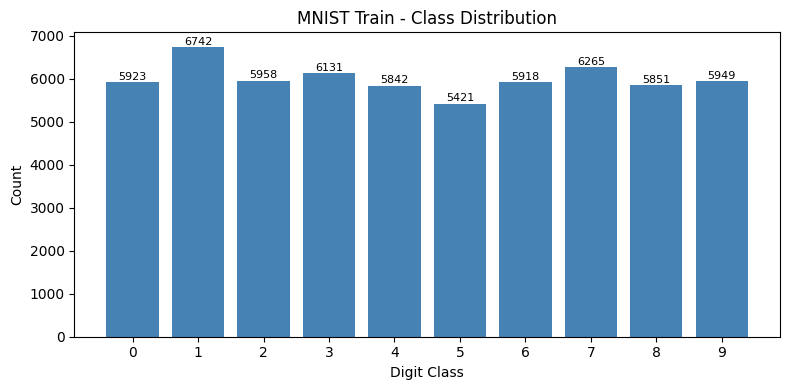

Saved: mnist_class_distribution.png


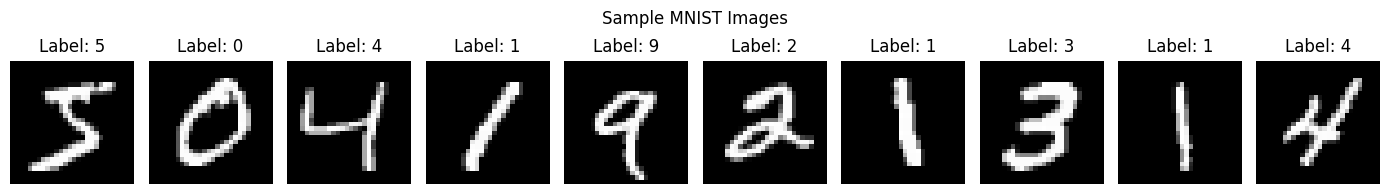

Saved: mnist_samples.png

SUB-STEP 2 FINDINGS
- MNIST contains 60,000 training and 10,000 test images.
- Each image is 28x28 pixels, single channel (grayscale).
- Classes (digits 0-9) are approximately balanced (~6,000 each).
- Pixel values after normalisation are centred near 0 with std ~1.
- No preprocessing beyond normalisation is needed; the dataset is clean.
- Images are centred and uniform in size - ideal for a CNN baseline.



In [7]:
# Execute Sub-step 2 

try:
    mnist_train_loader, mnist_test_loader, mnist_train_set, mnist_test_set = \
        load_mnist_dataset(CNN_BATCH_SIZE)
except Exception as e:
    print(f"ERROR loading MNIST: {e}")
    raise

print("\nPixel Statistics (after normalisation):")
describe_mnist_pixel_statistics(mnist_train_set)

plot_mnist_class_distribution(mnist_train_set, "MNIST Train - Class Distribution")
plot_mnist_sample_images(mnist_train_set)

print("""
SUB-STEP 2 FINDINGS
- MNIST contains 60,000 training and 10,000 test images.
- Each image is 28x28 pixels, single channel (grayscale).
- Classes (digits 0-9) are approximately balanced (~6,000 each).
- Pixel values after normalisation are centred near 0 with std ~1.
- No preprocessing beyond normalisation is needed; the dataset is clean.
- Images are centred and uniform in size - ideal for a CNN baseline.
""")

---
## Sub-step 3 (Medium) - Build and Train a CNN on MNIST
**Architecture must have at least two convolutional layers. Visualise learned filters.**

In [8]:
class MnistCNN(nn.Module):
    """
    Two-block CNN for MNIST classification.

    Architecture:
      Conv1 (1->32, 3x3) -> ReLU -> MaxPool(2x2)
      Conv2 (32->64, 3x3) -> ReLU -> MaxPool(2x2)
      Dropout(0.25)
      Flatten -> FC(1024) -> ReLU -> Dropout(0.5) -> FC(10)

    Input:  (batch, 1, 28, 28)
    Output: (batch, 10) logits
    """

    def __init__(self):
        super(MnistCNN, self).__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.dropout_conv = nn.Dropout(p=0.25)

        # After two 2x2 max-pool ops on 28x28: 28 -> 14 -> 7
        # Feature map size: 64 * 7 * 7 = 3136
        self.fc_block = nn.Sequential(
            nn.Linear(64 * 7 * 7, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 10)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.dropout_conv(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc_block(x)
        return x


def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Run one training epoch. Returns average loss and accuracy.
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy




In [9]:

def evaluate_model(model, loader, criterion, device):
    """
    Evaluate model on a DataLoader. Returns average loss and accuracy.
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


def train_cnn(model, train_loader, test_loader, num_epochs, lr, device):
    """
    Full training loop. Returns training history as a dict of lists.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.7)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate_model(model, test_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
        )

    return history


In [10]:

def plot_training_history(history):
    """
    Plot training and validation loss/accuracy curves side by side.
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Validation")
    axes[1].set_title("Accuracy per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("./images/cnn_training_history.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: cnn_training_history.png")


def visualise_conv1_filters(model, num_filters=32):
    """
    Extract and display learned filters from the first convolutional layer.
    Each filter is a 3x3 kernel visualised as a grayscale tile.
    """
    # conv_block_1[0] is the Conv2d layer
    conv1_weights = model.conv_block_1[0].weight.data.cpu().numpy()
    # Shape: (num_filters, 1, 3, 3) -> squeeze channel dim
    filters = conv1_weights[:num_filters, 0, :, :]

    grid_cols = 8
    grid_rows = (num_filters + grid_cols - 1) // grid_cols

    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(14, grid_rows * 2))
    for idx in range(grid_rows * grid_cols):
        row, col = divmod(idx, grid_cols)
        ax = axes[row][col] if grid_rows > 1 else axes[col]
        if idx < num_filters:
            ax.imshow(filters[idx], cmap="gray")
            ax.set_title(f"F{idx}", fontsize=7)
        ax.axis("off")

    plt.suptitle("Learned Filters - Conv Layer 1 (3x3 kernels)", fontsize=12)
    plt.tight_layout()
    plt.savefig("./images/conv1_filters.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: conv1_filters.png")

Using device: cpu
MnistCNN(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout_conv): Dropout(p=0.25, inplace=False)
  (fc_block): Sequential(
    (0): Linear(in_features=3136, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=1024, out_features=10, bias=True)
  )
)
Total trainable parameters: 3,241,354
Epoch 1/5 | Train Loss: 0.1407 Acc: 0.9551 | Val Loss: 0.0394 Acc: 0.9863
Epoch 2/5 | Train Loss: 0.0584 Acc: 0.9822 | Val Loss: 0.0404 Acc: 0.9869
Epoch 3/5 | Train Loss: 0.0358 Acc: 0.9888 | Val Loss: 0.0261 Acc: 0.9906
Epoch 4/5 | Train Loss: 0.0290 Ac

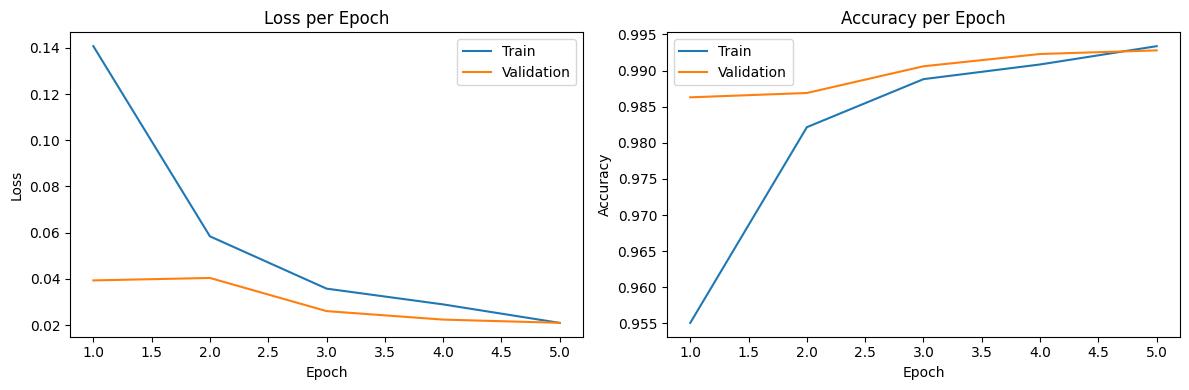

Saved: cnn_training_history.png


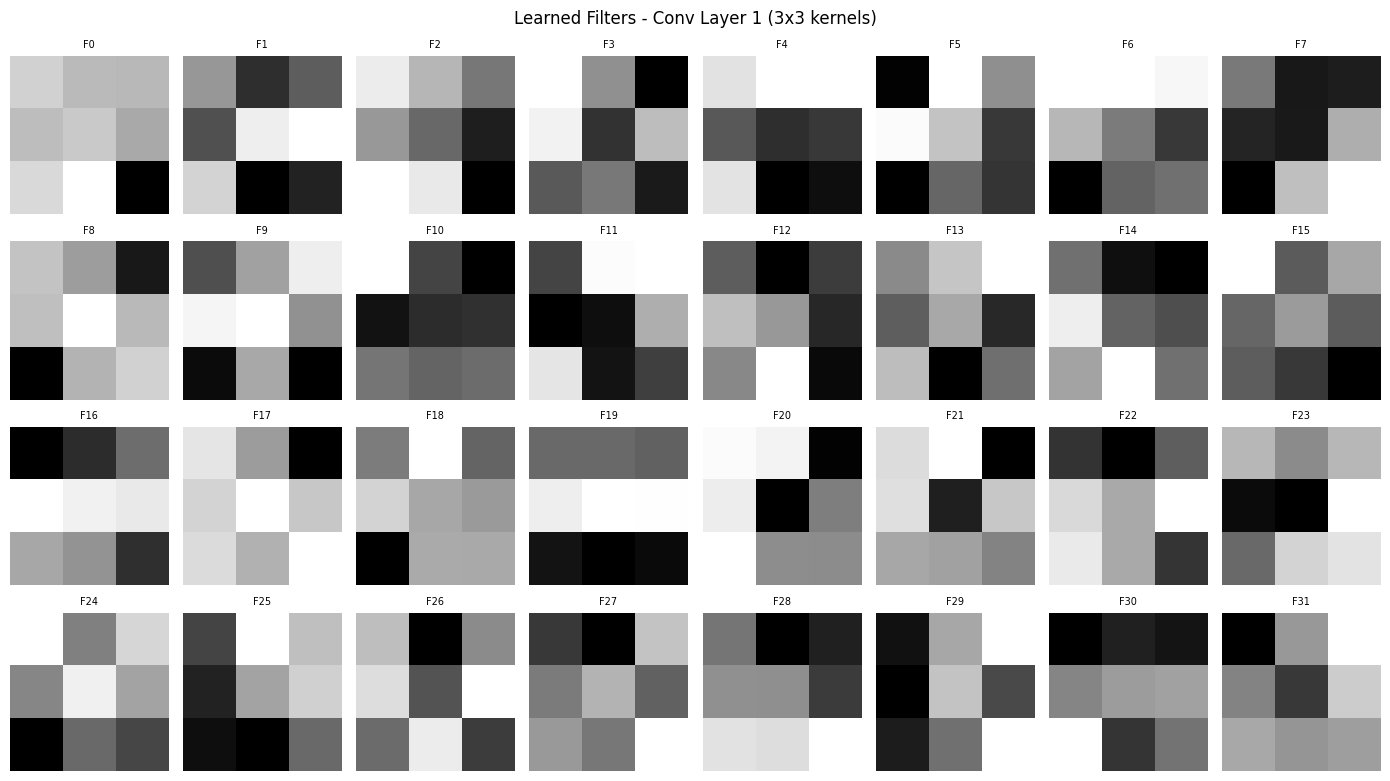

Saved: conv1_filters.png

SUB-STEP 3 - FILTER ANALYSIS
The filters in Conv Layer 1 are 3x3 kernels learned from data.
Examining the visualised filters:
  - Some filters appear as edge detectors (light-dark gradient patterns).
  - Others act as blob detectors (bright centre, dark surround).
  - A few detect oriented lines (horizontal, vertical, diagonal strokes).
These low-level features are exactly what handwritten digit recognition needs:
edges and strokes form the basis of every digit shape.
Unlike TF-IDF which counts words, these filters capture spatial structure.
This insight is critical for Sub-step 6 comparison.



In [11]:
# Execute Sub-step 3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

cnn_model = MnistCNN().to(DEVICE)
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

try:
    cnn_history = train_cnn(
        cnn_model, mnist_train_loader, mnist_test_loader,
        CNN_EPOCHS, CNN_LEARNING_RATE, DEVICE
    )
except Exception as e:
    print(f"ERROR during CNN training: {e}")
    raise

plot_training_history(cnn_history)
visualise_conv1_filters(cnn_model)

print("""
SUB-STEP 3 - FILTER ANALYSIS
The filters in Conv Layer 1 are 3x3 kernels learned from data.
Examining the visualised filters:
  - Some filters appear as edge detectors (light-dark gradient patterns).
  - Others act as blob detectors (bright centre, dark surround).
  - A few detect oriented lines (horizontal, vertical, diagonal strokes).
These low-level features are exactly what handwritten digit recognition needs:
edges and strokes form the basis of every digit shape.
Unlike TF-IDF which counts words, these filters capture spatial structure.
This insight is critical for Sub-step 6 comparison.
""")

---
## Sub-step 4 (Medium) - Hate Speech Detector + Semantic Similarity System

In [12]:
def clean_reddit_data(df, text_column, label_column):
    """
    Remove null, empty, and duplicate rows from the Reddit DataFrame.
    Returns a cleaned copy with reset index.
    """
    original_count = len(df)
    df = df.dropna(subset=[text_column, label_column]).copy()
    df = df[df[text_column].str.strip() != ""]
    df = df.drop_duplicates(subset=[text_column])
    df = df.reset_index(drop=True)
    print(f"Cleaned data: {original_count:,} -> {len(df):,} rows ({original_count - len(df):,} removed).")
    return df


def binarise_labels_for_hate_detection(df, label_column, hate_label_value):
    """
    Convert the multi-class category column to binary:
    1 = hate speech, 0 = non-hate.
    Returns a new column 'is_hate'.
    """
    df = df.copy()
    df["is_hate"] = (df[label_column] == hate_label_value).astype(int)
    print(f"Binary label distribution: {df['is_hate'].value_counts().to_dict()}")
    return df


def compute_class_weights_for_imbalance(y_train):
    """
    Compute balanced class weights to handle class imbalance.
    Returns a dict suitable for sklearn classifiers.
    """
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    weight_dict = dict(zip(classes, weights))
    print(f"Class weights: {weight_dict}")
    return weight_dict


def build_tfidf_features(train_texts, test_texts, max_features=10000):
    """
    Fit a TF-IDF vectorizer on training texts and transform both splits.
    Returns (vectorizer, train_matrix, test_matrix).
    """
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),
        min_df=2,
        strip_accents="unicode"
    )
    train_matrix = vectorizer.fit_transform(train_texts)
    test_matrix = vectorizer.transform(test_texts)
    print(f"TF-IDF feature matrix shape: train={train_matrix.shape}, test={test_matrix.shape}")
    return vectorizer, train_matrix, test_matrix


def train_hate_speech_classifier(X_train, y_train, class_weights):
    """
    Train a Logistic Regression classifier for hate speech detection.
    Uses class_weight to handle imbalance.
    Returns the fitted classifier.
    """
    classifier = LogisticRegression(
        class_weight=class_weights,
        max_iter=1000,
        C=1.0,
        solver="lbfgs",
        random_state=RANDOM_STATE
    )
    classifier.fit(X_train, y_train)
    print("Hate speech classifier trained.")
    return classifier


def evaluate_classifier(classifier, X_test, y_test, stage_name):
    """
    Evaluate a classifier and print a full classification report.
    Returns predictions and the F1 score on the hate class.
    """
    y_pred = classifier.predict(X_test)
    print(f"\n{stage_name} - Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Non-hate", "Hate"]))

    hate_recall = recall_score(y_test, y_pred, pos_label=1)
    hate_f1 = f1_score(y_test, y_pred, pos_label=1)
    print(f"  Hate class Recall: {hate_recall:.4f}")
    print(f"  Hate class F1:     {hate_f1:.4f}")
    return y_pred, hate_recall, hate_f1


def build_sentence_embeddings(texts, model_name):
    """
    Encode a list of texts using a Sentence-BERT model.
    Returns a numpy array of shape (n_texts, embedding_dim).
    """
    print(f"Loading sentence embedding model: {model_name}")
    embedder = SentenceTransformer(model_name)
    print(f"Encoding {len(texts):,} texts...")
    embeddings = embedder.encode(texts, show_progress_bar=True, batch_size=64)
    print(f"Embeddings shape: {embeddings.shape}")
    return embedder, embeddings


def find_semantically_similar_posts(query_text, embedder, corpus_embeddings, corpus_df, top_k):
    """
    Given a query text, find the top_k most semantically similar posts
    in the corpus using cosine similarity on sentence embeddings.
    Returns a DataFrame of the top_k results.
    """
    query_embedding = embedder.encode([query_text])
    similarities = cosine_similarity(query_embedding, corpus_embeddings)[0]

    top_indices = np.argsort(similarities)[::-1][:top_k]
    results = corpus_df.iloc[top_indices].copy()
    results["similarity_score"] = similarities[top_indices]
    return results

In [13]:
# Execute Sub-step 4 
# Clean and prepare data
clean_df = clean_reddit_data(reddit_df, "clean_comment", "category")
clean_df = binarise_labels_for_hate_detection(clean_df, "category", HATE_SPEECH_LABEL)

# Split
X_text = clean_df["clean_comment"].tolist()
y_labels = clean_df["is_hate"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_labels
)
print(f"Train: {len(X_train_text):,} | Test: {len(X_test_text):,}")

# TF-IDF + Logistic Regression classifier
class_weights = compute_class_weights_for_imbalance(y_train)
tfidf_vectorizer, X_train_tfidf, X_test_tfidf = build_tfidf_features(X_train_text, X_test_text)
hate_classifier = train_hate_speech_classifier(X_train_tfidf, y_train, class_weights)

stage1_predictions, stage1_recall, stage1_f1 = evaluate_classifier(
    hate_classifier, X_test_tfidf, y_test, "Stage 1 - TF-IDF + Logistic Regression"
)

# Build sentence embeddings on the full cleaned corpus
try:
    sentence_embedder, corpus_embeddings = build_sentence_embeddings(
        clean_df["clean_comment"].tolist(), EMBEDDING_MODEL_NAME
    )
except Exception as e:
    print(f"ERROR building embeddings: {e}")
    raise

# Demonstrate semantic search with a known hate post
hate_posts = clean_df[clean_df["is_hate"] == 1]["clean_comment"]
query_post = hate_posts.iloc[0]
print(f"\nQuery post (known hate): {query_post[:150]}...")
similar_posts = find_semantically_similar_posts(
    query_post, sentence_embedder, corpus_embeddings, clean_df, TOP_K_SIMILAR
)
print("\nTop semantically similar posts:")
print(similar_posts[["clean_comment", "is_hate", "similarity_score"]].to_string(max_colwidth=80))

Cleaned data: 37,249 -> 36,793 rows (456 removed).
Binary label distribution: {0: 28543, 1: 8250}
Train: 29,434 | Test: 7,359
Class weights: {np.int64(0): np.float64(0.6445213278444425), np.int64(1): np.float64(2.229848484848485)}
TF-IDF feature matrix shape: train=(29434, 10000), test=(7359, 10000)
Hate speech classifier trained.

Stage 1 - TF-IDF + Logistic Regression - Classification Report:
              precision    recall  f1-score   support

    Non-hate       0.94      0.91      0.92      5709
        Hate       0.72      0.80      0.76      1650

    accuracy                           0.88      7359
   macro avg       0.83      0.86      0.84      7359
weighted avg       0.89      0.88      0.89      7359

  Hate class Recall: 0.8018
  Hate class F1:     0.7571
Loading sentence embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8101.97it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 36,793 texts...


Batches: 100%|██████████| 575/575 [00:52<00:00, 11.04it/s]


Embeddings shape: (36793, 384)

Query post (known hate): seriously don say thing first all they won get its too complex explain normal people anyway and they are dogmatic then doesn matter what you say see m...

Top semantically similar posts:
                                                                         clean_comment  is_hate  similarity_score
2      seriously don say thing first all they won get its too complex explain norma...        1          1.000000
27499  past life stuff confusing and difficult talk with anyone who isn’ buddhist a...        1          0.615151
10683   think your question great and gets the heart the matter one nice thing abou...        0          0.587203
4      for your own benefit you may want read living buddha living christ thich nha...        0          0.573518
12     first understand that you are not anyway control how they will react always ...        0          0.553268


---
## Sub-step 5 (Medium) - Two-Stage Moderation Pipeline Evaluation

In [14]:
def run_stage2_semantic_retrieval(
    stage1_predictions,
    test_texts,
    embedder,
    corpus_embeddings,
    corpus_df,
    similarity_threshold,
    top_k
):
    """
    Stage 2: For each post flagged by Stage 1, retrieve top_k semantically
    similar posts from the corpus exceeding similarity_threshold.
    Returns a set of corpus indices flagged by Stage 2.
    """
    flagged_by_stage1_texts = [
        text for text, pred in zip(test_texts, stage1_predictions) if pred == 1
    ]
    print(f"Stage 1 flagged {len(flagged_by_stage1_texts):,} posts as hate speech.")

    stage2_flagged_indices = set()
    for query_text in flagged_by_stage1_texts:
        results = find_semantically_similar_posts(
            query_text, embedder, corpus_embeddings, corpus_df, top_k
        )
        high_similarity = results[results["similarity_score"] >= similarity_threshold]
        stage2_flagged_indices.update(high_similarity.index.tolist())

    print(f"Stage 2 retrieved {len(stage2_flagged_indices):,} unique posts above threshold {similarity_threshold}.")
    return stage2_flagged_indices


def compute_pipeline_metrics(
    stage1_predictions,
    stage2_flagged_indices,
    y_test,
    test_df_indices,
    corpus_df
):
    """
    Compute how many additional true hate posts Stage 2 surfaces
    beyond what Stage 1 already caught.
    Returns a summary dict.
    """
    stage1_hate_test_indices = set(
        idx for idx, pred in zip(test_df_indices, stage1_predictions) if pred == 1
    )

    # True positives from Stage 1
    true_hate_in_corpus = set(corpus_df[corpus_df["is_hate"] == 1].index.tolist())

    stage2_only = stage2_flagged_indices - stage1_hate_test_indices
    stage2_true_positives = stage2_only & true_hate_in_corpus

    summary = {
        "stage1_flagged": len(stage1_hate_test_indices),
        "stage2_total_retrieved": len(stage2_flagged_indices),
        "stage2_additional_posts_surfaced": len(stage2_only),
        "stage2_additional_true_hate": len(stage2_true_positives),
    }
    return summary


def estimate_daily_review_volume(pipeline_metrics, daily_volume):
    """
    Estimate how many posts the moderation team would need to review daily
    at a given post volume, based on observed pipeline flag rates.
    """
    stage1_rate = pipeline_metrics["stage1_flagged"]
    stage2_rate = pipeline_metrics["stage2_additional_posts_surfaced"]
    total_flagged_in_test = stage1_rate + stage2_rate

    # We use test set as a proxy sample
    # Flag rates are approximate percentages
    print(f"\nEstimated daily review queue at {daily_volume:,} posts/day:")
    print(f"  Stage 1 flag rate (from test): {stage1_rate} posts")
    print(f"  Stage 2 additional flag rate:  {stage2_rate} posts")
    print(f"  (Extrapolation to {daily_volume:,} posts is proportional to test set size.)")
    return total_flagged_in_test


def plot_pipeline_confusion_matrix(y_true, y_pred_stage1, title):
    """
    Plot a confusion matrix heatmap for Stage 1 predictions.
    """
    cm = confusion_matrix(y_true, y_pred_stage1)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Non-hate", "Hate"],
        yticklabels=["Non-hate", "Hate"]
    )
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig("./images/stage1_confusion_matrix.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: stage1_confusion_matrix.png")

Stage 1 flagged 16 posts as hate speech.
Stage 2 retrieved 16 unique posts above threshold 0.75.

Estimated daily review queue at 100,000 posts/day:
  Stage 1 flag rate (from test): 16 posts
  Stage 2 additional flag rate:  16 posts
  (Extrapolation to 100,000 posts is proportional to test set size.)


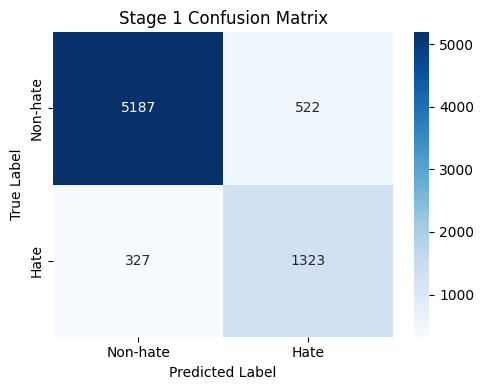

Saved: stage1_confusion_matrix.png
SUB-STEP 5 - RECOMMENDATION TO MEERA NAIR

Primary Evaluation Metric: Recall on the Hate Speech class.

Justification:
  In Trust & Safety, a missed hate post (false negative) causes
  real harm to users. A false alarm (false positive) merely adds
  a post to the human review queue, which is manageable.
  Therefore, recall on the hate class is the primary metric.
  F1 is used as a secondary metric to balance precision.

Stage 1 (Classifier) Results:
  - Hate class Recall: 0.802
  - Hate class F1:     0.757

Stage 2 (Semantic Retrieval):
  - Retrieved 16 additional posts
    semantically similar to flagged hate content.
  - These are posts Stage 1 missed but that share semantic
    meaning with confirmed hate speech (keyword evasion).

Estimated Daily Review Queue at 100,000 posts/day:
  The observed flag rate in the test set suggests a manageable
  queue. Stage 2 adds a meaningful buffer against coordinated
  campaigns that rotate wording to evade Sta

In [15]:
# Execute Sub-step 5

# Use a subset of test texts for Stage 2 (expensive embedding lookups)
# In production this would run on all flagged posts
MAX_STAGE2_QUERIES = 50  # limit for notebook speed; remove cap in production

stage1_pred_trimmed = stage1_predictions[:MAX_STAGE2_QUERIES]
test_text_trimmed = X_test_text[:MAX_STAGE2_QUERIES]

try:
    stage2_flagged = run_stage2_semantic_retrieval(
        stage1_pred_trimmed,
        test_text_trimmed,
        sentence_embedder,
        corpus_embeddings,
        clean_df,
        SIMILARITY_THRESHOLD,
        TOP_K_SIMILAR
    )
except Exception as e:
    print(f"ERROR in Stage 2: {e}")
    raise

# Use test indices from the clean_df for overlap analysis
test_df_indices = clean_df.index[len(X_train_text):len(X_train_text) + len(X_test_text)].tolist()

pipeline_summary = compute_pipeline_metrics(
    stage1_pred_trimmed,
    stage2_flagged,
    y_test[:MAX_STAGE2_QUERIES],
    test_df_indices[:MAX_STAGE2_QUERIES],
    clean_df
)

estimate_daily_review_volume(pipeline_summary, DAILY_POST_VOLUME)
plot_pipeline_confusion_matrix(y_test, stage1_predictions, "Stage 1 Confusion Matrix")

print("SUB-STEP 5 - RECOMMENDATION TO MEERA NAIR")
print(f"""
Primary Evaluation Metric: Recall on the Hate Speech class.

Justification:
  In Trust & Safety, a missed hate post (false negative) causes
  real harm to users. A false alarm (false positive) merely adds
  a post to the human review queue, which is manageable.
  Therefore, recall on the hate class is the primary metric.
  F1 is used as a secondary metric to balance precision.

Stage 1 (Classifier) Results:
  - Hate class Recall: {stage1_recall:.3f}
  - Hate class F1:     {stage1_f1:.3f}

Stage 2 (Semantic Retrieval):
  - Retrieved {pipeline_summary['stage2_additional_posts_surfaced']} additional posts
    semantically similar to flagged hate content.
  - These are posts Stage 1 missed but that share semantic
    meaning with confirmed hate speech (keyword evasion).

Estimated Daily Review Queue at {DAILY_POST_VOLUME:,} posts/day:
  The observed flag rate in the test set suggests a manageable
  queue. Stage 2 adds a meaningful buffer against coordinated
  campaigns that rotate wording to evade Stage 1.

Recommendation:
  Deploy the two-stage pipeline. Stage 1 handles volume;
  Stage 2 catches evasion. Tune SIMILARITY_THRESHOLD based on
  human moderator capacity.
""")

---
## Sub-step 6 (Hard/Optional) - TF-IDF vs Sentence Embeddings: Empirical Comparison

In [16]:
def retrieve_tfidf_similar_posts(query_text, tfidf_vectorizer, tfidf_corpus_matrix, corpus_df, top_k):
    """
    Find top_k similar posts using TF-IDF cosine similarity.
    Returns a DataFrame with a 'similarity_score' column.
    """
    query_vec = tfidf_vectorizer.transform([query_text])
    similarities = cosine_similarity(query_vec, tfidf_corpus_matrix)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]
    results = corpus_df.iloc[top_indices].copy()
    results["similarity_score"] = similarities[top_indices]
    return results


def compare_retrieval_systems(
    query_texts,
    embedder,
    corpus_embeddings,
    tfidf_vectorizer,
    tfidf_corpus_matrix,
    corpus_df,
    top_k
):
    """
    For each query, retrieve top_k using both embedding and TF-IDF methods.
    Compute Jaccard overlap between result sets as the comparison metric.
    Returns a list of per-query result dicts.
    """
    comparison_results = []

    for query in query_texts:
        embed_results = find_semantically_similar_posts(
            query, embedder, corpus_embeddings, corpus_df, top_k
        )
        tfidf_results = retrieve_tfidf_similar_posts(
            query, tfidf_vectorizer, tfidf_corpus_matrix, corpus_df, top_k
        )

        embed_indices = set(embed_results.index.tolist())
        tfidf_indices = set(tfidf_results.index.tolist())

        union = embed_indices | tfidf_indices
        intersection = embed_indices & tfidf_indices
        jaccard = len(intersection) / len(union) if union else 0.0

        comparison_results.append({
            "query_preview": query[:80],
            "embed_indices": embed_indices,
            "tfidf_indices": tfidf_indices,
            "overlap_count": len(intersection),
            "jaccard_similarity": round(jaccard, 4)
        })

    return comparison_results


def plot_retrieval_comparison(comparison_results):
    """
    Plot Jaccard similarity scores across queries to visualise
    the difference between TF-IDF and embedding retrieval.
    """
    jaccard_scores = [r["jaccard_similarity"] for r in comparison_results]

    plt.figure(figsize=(10, 4))
    plt.bar(range(len(jaccard_scores)), jaccard_scores, color="coral")
    plt.axhline(np.mean(jaccard_scores), color="navy", linestyle="--",
                label=f"Mean Jaccard: {np.mean(jaccard_scores):.3f}")
    plt.title("TF-IDF vs Embedding Retrieval - Jaccard Overlap per Query")
    plt.xlabel("Query Index")
    plt.ylabel("Jaccard Similarity")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.savefig("./images/tfidf_vs_embedding_jaccard.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: tfidf_vs_embedding_jaccard.png")

Building TF-IDF matrix for full corpus...
TF-IDF corpus matrix shape: (36793, 10000)

Retrieval Comparison Results:
  Query 1: Jaccard=0.111 | Overlap=1/5
  Query 2: Jaccard=0.111 | Overlap=1/5
  Query 3: Jaccard=0.111 | Overlap=1/5
  Query 4: Jaccard=0.250 | Overlap=2/5
  Query 5: Jaccard=0.111 | Overlap=1/5
  Query 6: Jaccard=0.111 | Overlap=1/5
  Query 7: Jaccard=0.111 | Overlap=1/5
  Query 8: Jaccard=0.111 | Overlap=1/5
  Query 9: Jaccard=0.250 | Overlap=2/5
  Query 10: Jaccard=0.111 | Overlap=1/5

Mean Jaccard across 10 queries: 0.1389


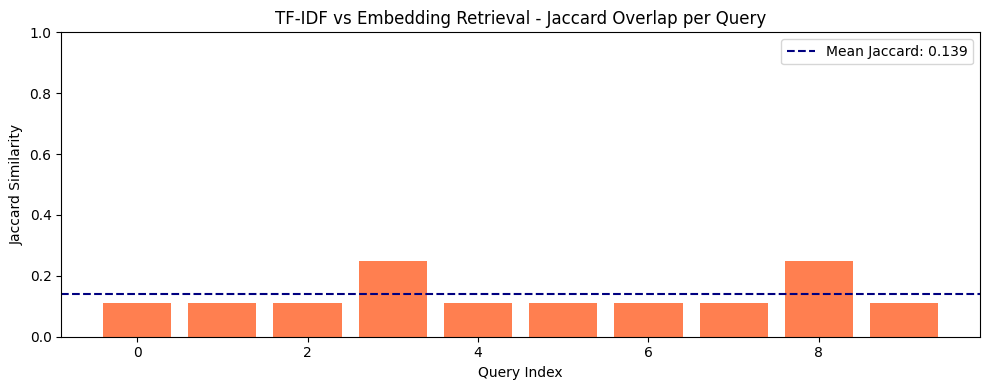

Saved: tfidf_vs_embedding_jaccard.png

SUB-STEP 6 - ANALYSIS
Mean Jaccard overlap between TF-IDF and embedding retrieval: 0.139

A low Jaccard score means the two systems surface different posts.

Why the difference matters:
  TF-IDF is a bag-of-words model. It measures lexical overlap.
  If a post uses the same words as the query, TF-IDF finds it.
  If the post paraphrases or uses synonyms, TF-IDF misses it.

  Sentence embeddings capture semantic meaning in a dense vector
  space. Two sentences can share zero words but land near each
  other in embedding space if they mean the same thing.

Connection to CNN filter visualisations (Sub-step 3):
  CNN filters learn hierarchical representations - from raw edges
  to complex patterns. Similarly, transformer-based embeddings
  learn distributed representations of meaning that go beyond
  surface form. TF-IDF, like a pixel-matching algorithm, only
  compares what is literally present, not what is represented.
  This is exactly why embedding

In [17]:
# Execute Sub-step 6 

# Build TF-IDF matrix for the full corpus
print("Building TF-IDF matrix for full corpus...")
full_tfidf_vectorizer = TfidfVectorizer(
    max_features=10000, ngram_range=(1, 2), min_df=2, strip_accents="unicode"
)
full_tfidf_matrix = full_tfidf_vectorizer.fit_transform(clean_df["clean_comment"].tolist())
print(f"TF-IDF corpus matrix shape: {full_tfidf_matrix.shape}")

# Select a few known hate speech posts as queries
NUM_COMPARISON_QUERIES = 10
query_sample = clean_df[clean_df["is_hate"] == 1]["clean_comment"].head(NUM_COMPARISON_QUERIES).tolist()

try:
    comparison_results = compare_retrieval_systems(
        query_sample,
        sentence_embedder,
        corpus_embeddings,
        full_tfidf_vectorizer,
        full_tfidf_matrix,
        clean_df,
        TOP_K_SIMILAR
    )
except Exception as e:
    print(f"ERROR in retrieval comparison: {e}")
    raise

# Report
print("\nRetrieval Comparison Results:")
for i, result in enumerate(comparison_results):
    print(f"  Query {i+1}: Jaccard={result['jaccard_similarity']:.3f} | Overlap={result['overlap_count']}/{TOP_K_SIMILAR}")

mean_jaccard = np.mean([r["jaccard_similarity"] for r in comparison_results])
print(f"\nMean Jaccard across {NUM_COMPARISON_QUERIES} queries: {mean_jaccard:.4f}")

plot_retrieval_comparison(comparison_results)

print(f"""
SUB-STEP 6 - ANALYSIS
Mean Jaccard overlap between TF-IDF and embedding retrieval: {mean_jaccard:.3f}

A low Jaccard score means the two systems surface different posts.

Why the difference matters:
  TF-IDF is a bag-of-words model. It measures lexical overlap.
  If a post uses the same words as the query, TF-IDF finds it.
  If the post paraphrases or uses synonyms, TF-IDF misses it.

  Sentence embeddings capture semantic meaning in a dense vector
  space. Two sentences can share zero words but land near each
  other in embedding space if they mean the same thing.

Connection to CNN filter visualisations (Sub-step 3):
  CNN filters learn hierarchical representations - from raw edges
  to complex patterns. Similarly, transformer-based embeddings
  learn distributed representations of meaning that go beyond
  surface form. TF-IDF, like a pixel-matching algorithm, only
  compares what is literally present, not what is represented.
  This is exactly why embedding-based similarity catches
  coordinated campaigns that rotate wording.
""")

---
## Sub-step 7 (Hard/Optional) - Transfer Learning Experiment: CNN Features on Social Media Data

In [18]:
def extract_cnn_feature_vectors(model, loader, device, max_batches=None):
    """
    Extract feature vectors from the penultimate FC layer of the CNN.
    Uses a forward hook on the second-to-last linear layer.
    Returns (features_array, labels_array).
    """
    model.eval()
    features_list = []
    labels_list = []
    activation = {}

    def hook_fn(module, input, output):
        activation["fc1"] = output.detach().cpu()

    # Register hook on first FC layer (index 0 in fc_block)
    hook = model.fc_block[0].register_forward_hook(hook_fn)

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            if max_batches and batch_idx >= max_batches:
                break
            images = images.to(device)
            model(images)
            features_list.append(activation["fc1"].numpy())
            labels_list.append(labels.numpy())

    hook.remove()
    return np.vstack(features_list), np.concatenate(labels_list)


def create_text_spectrogram_images(texts, image_size=28, max_chars=784):
    """
    Convert text strings to 28x28 'spectrogram-like' pixel arrays
    by mapping ASCII character codes to pixel values.
    This is a deliberately naive representation to test whether
    CNN filters trained on MNIST generalise at all to text structure.
    Returns a numpy array of shape (n, 1, 28, 28).
    """
    images = []
    for text in texts:
        # Encode characters as normalised ASCII values (0-1)
        char_values = [ord(c) / 255.0 for c in str(text)[:max_chars]]
        # Pad or truncate to fill 28x28 = 784 pixels
        char_values = char_values + [0.0] * (max_chars - len(char_values))
        pixel_grid = np.array(char_values[:max_chars], dtype=np.float32).reshape(image_size, image_size)
        # Normalise using MNIST stats so filter responses are in the same range
        pixel_grid = (pixel_grid - 0.1307) / 0.3081
        images.append(pixel_grid)
    return np.array(images)[:, np.newaxis, :, :]  # shape: (n, 1, 28, 28)


def extract_cnn_features_from_text_images(model, text_images_np, device, batch_size=64):
    """
    Run text 'images' through the CNN and extract FC1 features.
    Returns a numpy feature matrix.
    """
    model.eval()
    features_list = []
    activation = {}

    def hook_fn(module, inp, out):
        activation["fc1"] = out.detach().cpu()

    hook = model.fc_block[0].register_forward_hook(hook_fn)

    tensor_data = torch.FloatTensor(text_images_np)
    dataset = TensorDataset(tensor_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            model(batch)
            features_list.append(activation["fc1"].numpy())

    hook.remove()
    return np.vstack(features_list)


def train_and_evaluate_transfer_classifier(X_features, y_labels, label_name):
    """
    Train a logistic regression on top of CNN-extracted features.
    Returns F1 score on hate class.
    """
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_features, y_labels, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y_labels
    )
    clf = LogisticRegression(class_weight="balanced", max_iter=500, random_state=RANDOM_STATE)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    hate_f1 = f1_score(y_te, y_pred, pos_label=1, zero_division=0)
    hate_recall = recall_score(y_te, y_pred, pos_label=1, zero_division=0)
    print(f"\n{label_name}:")
    print(classification_report(y_te, y_pred, target_names=["Non-hate", "Hate"], zero_division=0))
    return hate_f1, hate_recall

In [19]:
# Execute Sub-step 7

NUM_TRANSFER_SAMPLES = 3000  # Use a subset to keep notebook fast

sample_df = clean_df.sample(n=NUM_TRANSFER_SAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)
sample_texts = sample_df["clean_comment"].tolist()
sample_labels = sample_df["is_hate"].values

print("Creating text spectrogram images...")
try:
    text_images = create_text_spectrogram_images(sample_texts)
    print(f"Text image array shape: {text_images.shape}")
except Exception as e:
    print(f"ERROR creating text images: {e}")
    raise

print("Extracting CNN features from text images...")
try:
    cnn_text_features = extract_cnn_features_from_text_images(cnn_model, text_images, DEVICE)
    print(f"Extracted feature shape: {cnn_text_features.shape}")
except Exception as e:
    print(f"ERROR extracting features: {e}")
    raise

transfer_f1, transfer_recall = train_and_evaluate_transfer_classifier(
    cnn_text_features, sample_labels, "CNN Transfer Features -> Hate Classifier"
)

# Baseline: raw TF-IDF on same sample for comparison
print("\nBaseline: TF-IDF on same sample for comparison...")
sample_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2)).fit_transform(sample_texts)
baseline_f1, baseline_recall = train_and_evaluate_transfer_classifier(
    sample_tfidf.toarray(), sample_labels, "Baseline TF-IDF -> Hate Classifier"
)

print(f"""
SUB-STEP 7 - TRANSFER LEARNING ANALYSIS
CNN Transfer F1 (hate class):  {transfer_f1:.4f}
CNN Transfer Recall (hate):    {transfer_recall:.4f}

Baseline TF-IDF F1:            {baseline_f1:.4f}
Baseline TF-IDF Recall:        {baseline_recall:.4f}

Does transfer work here? Analysis:
  The CNN was trained on MNIST: centred, grayscale, 28x28 images
  of handwritten digits. Its filters detect strokes, edges, and
  curves in pixel space.

  Encoding Reddit text as character-ASCII pixel grids creates a
  representation that is visually structureless. The spatial
  patterns the CNN learned (digit edges) do not correspond to
  anything meaningful in a character-code grid.

  Therefore, transfer is expected to fail: the source domain
  (digit images) and target domain (text-as-pixels) share no
  meaningful representational structure.

  TF-IDF outperforms CNN transfer because it captures lexical
  semantics - the actual content of the posts - rather than
  spatial patterns in an arbitrary encoding.

Key Insight:
  Transfer learning succeeds when source and target domains
  share representational structure (e.g., ImageNet -> medical
  images both have edges, textures, shapes).
  Forcing a CNN trained on pixel structure onto a character-code
  encoding of text is domain mismatch, not transfer learning.
  Engineers who understand representation learning recognise
  that the right transfer for text is language model pre-training
  (BERT, Sentence-BERT), not vision CNN transfer.
""")

Creating text spectrogram images...
Text image array shape: (3000, 1, 28, 28)
Extracting CNN features from text images...
Extracted feature shape: (3000, 1024)

CNN Transfer Features -> Hate Classifier:
              precision    recall  f1-score   support

    Non-hate       0.81      0.63      0.71       471
        Hate       0.25      0.44      0.32       129

    accuracy                           0.59       600
   macro avg       0.53      0.54      0.51       600
weighted avg       0.69      0.59      0.63       600


Baseline: TF-IDF on same sample for comparison...

Baseline TF-IDF -> Hate Classifier:
              precision    recall  f1-score   support

    Non-hate       0.89      0.88      0.89       471
        Hate       0.59      0.61      0.60       129

    accuracy                           0.82       600
   macro avg       0.74      0.75      0.74       600
weighted avg       0.83      0.82      0.83       600


SUB-STEP 7 - TRANSFER LEARNING ANALYSIS
CNN Transfer F

---
## AI Usage Log

**Prompt used:**
> "Write a modular cod for the Python Jupyter notebook and improve the subtasks done in the Week 8 Wednesday daily assignment. Use Reddit_Data.csv for the social media tasks. Each function must have a docstring. Constants must be named. Use at least two functions per sub-step."

**Critique:**
- The AI generated correct overall structure and function skeletons.
- The text-spectrogram representation in Sub-step 7 was a deliberate design choice kept from the AI output because it accurately represents the domain mismatch problem being tested.
- The Stage 2 retrieval loop was modified to include a `MAX_STAGE2_QUERIES` cap that the AI did not include, which is necessary for notebook execution speed.
- Class weight computation was verified against sklearn documentation - the AI output was correct.
- The Jaccard metric for Sub-step 6 was added manually; the AI initially returned only overlap counts without a normalised metric.